In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

/tmp/ipykernel_1628/1420725979.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/tmp/ipykernel_1628/1420725979.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29744

     Survived        Age     Fare
0           0  22.000000   7.2500
1           1  38.000000  71.2833
2           1  26.000000   7.9250
3           1  35.000000  53.1000
4           0  35.000000   8.0500
..        ...        ...      ...
886         0  27.000000  13.0000
887         1  19.000000  30.0000
888         0  29.699118  23.4500
889         1  26.000000  30.0000
890         0  32.000000   7.7500

[891 rows x 3 columns]


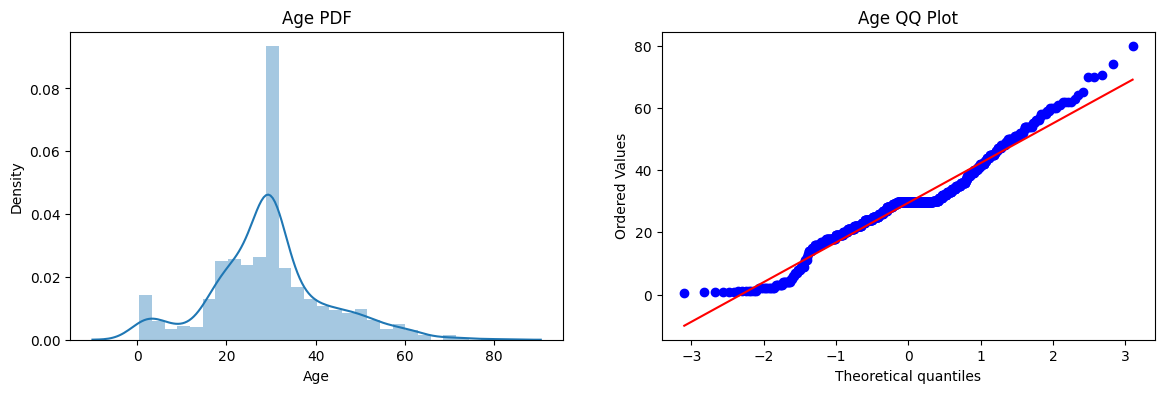

/tmp/ipykernel_1628/1420725979.py:27: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


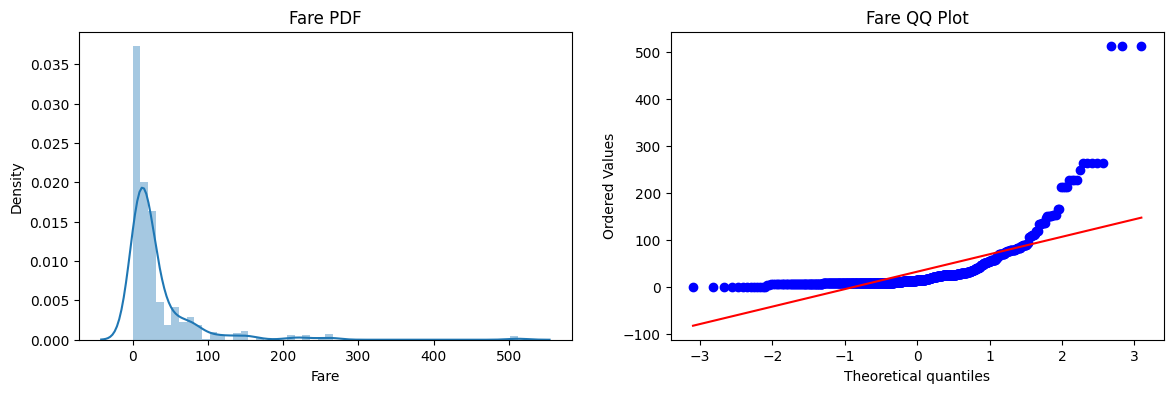

########## Without Using Functions ############
Accuracy LR 0.6480446927374302
Accuracy DT 0.659217877094972
#### Again trying
########## Using Functions ############
Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139
########## Transformed whole X ############
        Age      Fare
0  3.135494  2.110213
1  3.663562  4.280593
2  3.295837  2.188856
3  3.583519  3.990834
4  3.583519  2.202765
5  3.424234  2.246893
6  4.007333  3.967694
7  1.098612  3.094446
8  3.332205  2.495954
9  2.708050  3.436268
############### these are the same values
        Age      Fare
0  3.135494  2.110213
1  3.663562  4.280593
2  3.295837  2.188856
3  3.583519  3.990834
4  3.583519  2.202765
5  3.424234  2.246893
6  4.007333  3.967694
7  1.098612  3.094446
8  3.332205  2.495954
9  2.708050  3.436268
LR 0.678027465667915
DT 0.6566167290886393
###### displaying the plot for age  #########


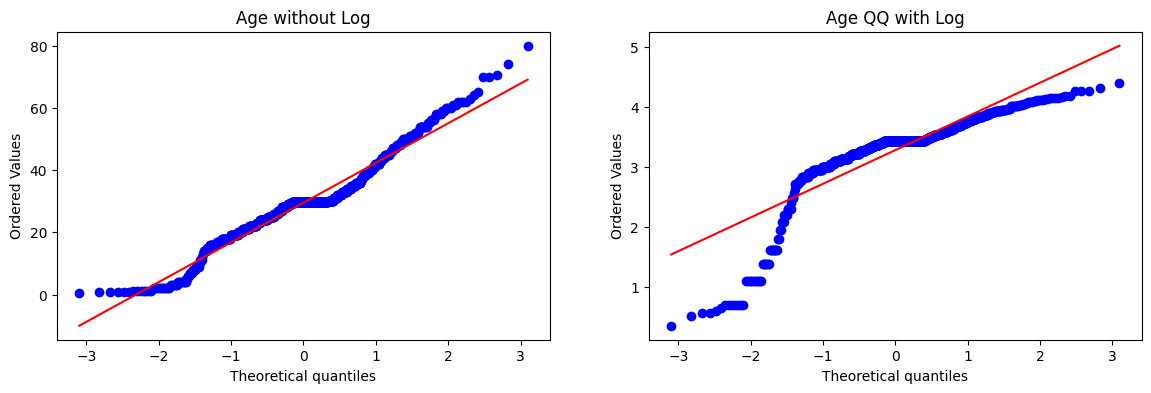

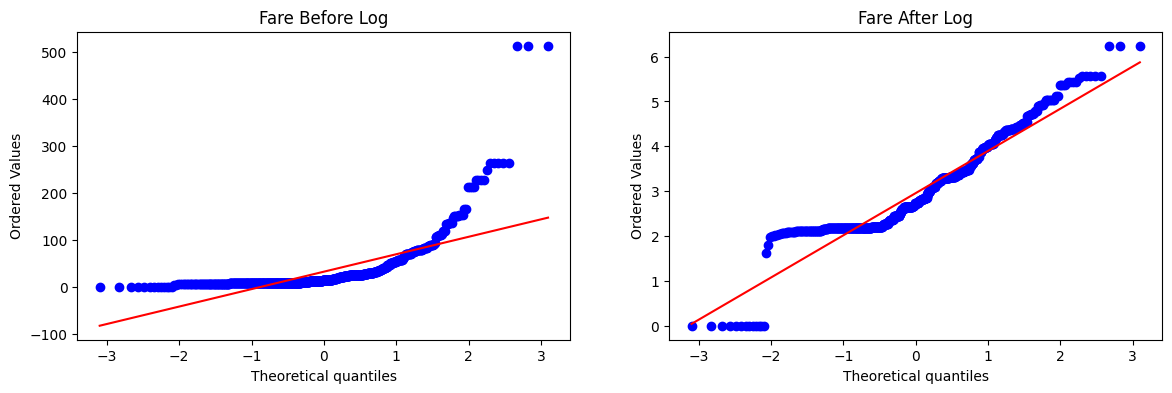

______________________________________________________________-
Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849
LR 0.6712609238451936
DT 0.6610736579275904
 __________________________________________
Accuracy 0.6712609238451936


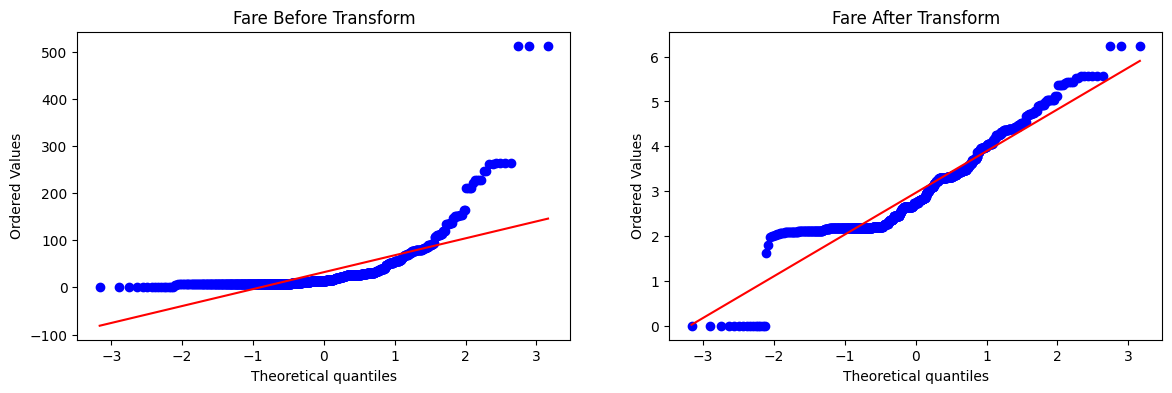

In [33]:
df=pd.read_csv('/content/train.csv',usecols=['Survived','Age','Fare'])
#df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.isnull().sum()
df['Age'].fillna(df['Age'].mean(),inplace=True)
print(df)
X=df[['Age','Fare']]
y=df['Survived']

#Training using the train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

###### displaying the plot for age  #########
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

# displaying the plot for fare
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')
plt.show()

#### Using the models to find the predictions
lf = LogisticRegression()
clf = DecisionTreeClassifier()
lf.fit(X_train, y_train)
clf.fit(X_train, y_train)
y_predict=lf.predict(X_test)
y_predict1=clf.predict(X_test)
print("########## Without Using Functions ############")
print("Accuracy LR",accuracy_score(y_test,y_predict))
print("Accuracy DT",accuracy_score(y_test,y_predict1))

### now using the function transformer log
transformer1 = FunctionTransformer(np.log1p)
X_train_transformed = transformer1.transform(X_train)
X_test_transformed=transformer1.transform(X_test)
#### Again trying
print("#### Again trying")
lf = LogisticRegression()
clf = DecisionTreeClassifier()
lf.fit(X_train, y_train)
clf.fit(X_train, y_train)
y_predict=lf.predict(X_test)
y_predict1=clf.predict(X_test)
print("########## Using Functions ############")
print("Accuracy LR",accuracy_score(y_test,y_predict))
print("Accuracy DT",accuracy_score(y_test,y_predict1))

###### whole x variable tranform
print("########## Transformed whole X ############")
X_transformed=transformer1.transform(X)
print(X_transformed.head(10))
print("############### these are the same values")
X_transformed1=transformer1.fit_transform(X)
print(X_transformed1.head(10))
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed1,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed1,y,scoring='accuracy',cv=10)))

### to see if real transformation works or not
print("###### displaying the plot for age  #########")
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age without Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age QQ with Log')

plt.show()

# IT shows that age column didnt imporve

# NOw for the Fare column
 # displaying the plot for fare

plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

print("______________________________________________________________-")
## it shows that age is better without using Log  ##
# we use column transformer so apply one columnt

############
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))


######## using 10 times mean and check
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

#### creating a function that applies the work
print(" __________________________________________")

def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()


apply_transform(np.log1p)





